In [44]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [5]:
#load tips data
raw_data = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
raw_data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [6]:
#inspecting/exporing the data
#check first five records
raw_data.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
#check last five records
raw_data.tail(5)

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [8]:
#check the shape of the dataset (number of raws and columns)
raw_data.shape

(244, 7)

In [11]:
#check generale overview of the data
raw_data.info

<bound method DataFrame.info of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [12]:
#check the data types of the columns
raw_data.dtypes

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

In [13]:
#check data summary
raw_data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [15]:
#checking for duplicates
raw_data.duplicated().sum()

np.int64(1)

In [16]:
#drop duplicate value
raw_data.drop_duplicates(inplace=True)

In [18]:
#rechecking duplicates
raw_data.duplicated().sum()

np.int64(0)

In [21]:
#a function checking for missing values
def missing_values(data):
    #total missing values per column in descending order
    miss = data.isnull().sum().sort_values(ascending=False)
    #percentange missing values per column in descending order
    percent_miss= (data.isnull().sum()/len(data)).sort_values(ascending=False)
    #store results in a dataframe for easy reading
    missing=pd.DataFrame({"Missing Values":miss, "Percentage missing":percent_miss})
    #drop values where missing values is zero
    missing=missing[missing["Missing Values"]>0]
    return missing

#check missing values
missing_tips = missing_values(raw_data)
missing_tips
    

,Missing Values,Percentage missing


In [22]:
#detecting outlier for the numeric values using box plots
#check column names
raw_data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

<Axes: >

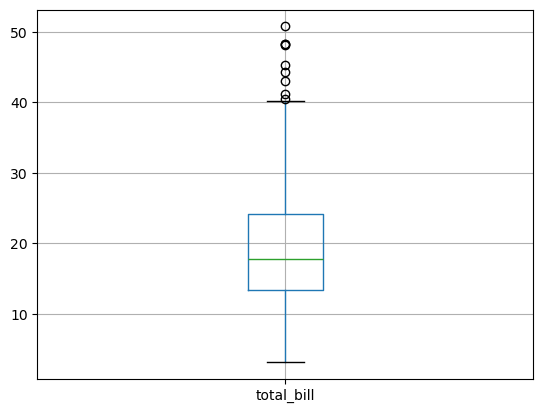

In [23]:
#box plot of the total bill
raw_data.boxplot(column='total_bill')

In [24]:
#box plot of the tip
raw_data.boxplot(column='tip')

<Axes: >

In [25]:
#box plot of the size
raw_data.boxplot(column='size')

<Axes: >

In [31]:
#relationship between our target variable tip and total bill and size
#define independent(X) and dependent(y)variables
y=raw_data['tip']
X=raw_data[['size','total_bill']]

In [49]:
#Add a constant to the X variable
X_=sm.add_constant(X)
X.head()

,const,size,total_bill
0,1.0,2,16.99
1,1.0,3,10.34
2,1.0,3,21.01
3,1.0,2,23.68
4,1.0,4,24.59


In [50]:
#training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size = 0.2,
                                                    random_state = 1502)

In [51]:
#Multilinear regression
model = sm.OLS(y_train,X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     85.89
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.47e-27
Time:                        17:44:50   Log-Likelihood:                -280.49
No. Observations:                 194   AIC:                             567.0
Df Residuals:                     191   BIC:                             576.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5814      0.221      2.635      0.0

In [52]:
# Making predictions on the test data
predictions = model.predict(X_test)
predictions[:10]

216    4.403987
161    2.235996
60     2.920406
197    5.486384
52     4.741875
3      3.224489
11     4.782240
192    3.651460
48     3.920840
220    2.191146
dtype: float64

In [53]:
#assessing the accuracy of the model
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, predictions)),1))

RMSE: 0.9


In [58]:
#plotting bar chart to visualize the findings
#extracting coefficients
coef=model.params.drop('const')

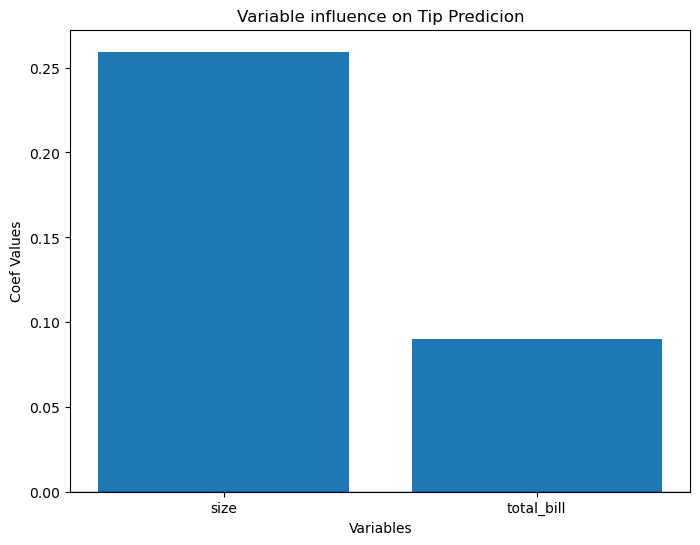

In [59]:
#creating bar chart
plt.figure(figsize=(8,6))
plt.bar(coef.index, coef.values)

plt.title("Variable influence on Tip Predicion")
plt.ylabel("Coef Values")
plt.xlabel("Variables")

plt.axhline(0, color="blue", linewidth=1)
plt.show()